# ART calculations for `Ebola` virus (Ebola + Zaire Ebola)

### Training data base `Pubchem + chEMBL`

In [12]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
sys.path.append(".")
sys.path.append('/users/sghosh6/DTRA_project/MACAW/AutomatedRecommendationTool')

import warning_utils
warning_utils.filter_end_user_warnings()

In [26]:
import pandas as pd
import numpy as np
from rdkit import Chem

from art.core import RecommendationEngine
import art.utility as utils
from art.plot import predictions_vs_observations, predictions_distr_vs_observations
import pickle
import cloudpickle
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import gc

### Define directories

In [56]:
dataDir = '/users/sghosh6/DTRA_project/MACAW/DTRA_ART/'
modelBuildingDataDir = os.path.join(dataDir + '/DrugDesignData/modelBuildingData/')
#resultsDir = os.path.join(dataDir, 'Results/')
artResultDir = dataDir + '/ART_CommandLine/Ebola_allDB/ART_results'
os.makedirs(artResultDir, exist_ok=True)
saveDir = os.path.join(dataDir + "/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/")
os.makedirs(saveDir, exist_ok=True)

### Extract the data for `Ebola` into a data frame with `duplicate` SMILES

In [32]:
combinedEbolaVirusData_allDB_wMACAW = pd.read_csv(modelBuildingDataDir + "combinedEbolaVirusData_allDB_wMACAW.csv")
combinedEbolaVirusData_allDB_wMACAW 

,ID,compound_id,Smiles,pPotency,StrainClassifier,pPotency_category,MACAW_1,MACAW_2,MACAW_3,MACAW_4,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,1,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola,3-10,0.237882,-0.055024,0.213845,-0.255485,...,0.004283,0.007330,-0.022609,0.023459,-0.044410,0.006911,0.004934,-0.013307,0.009132,0.055285
1,2,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola,3-10,0.237882,-0.055024,0.213845,-0.255485,...,0.004283,0.007330,-0.022609,0.023459,-0.044410,0.006911,0.004934,-0.013307,0.009132,0.055285
2,3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola,3-10,0.222323,-0.045034,0.171495,-0.234825,...,-0.037945,0.045591,-0.022954,-0.022400,-0.038090,0.040749,-0.006746,-0.013577,0.017598,0.024879
3,4,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola,3-10,0.222323,-0.045034,0.171495,-0.234825,...,-0.037945,0.045591,-0.022954,-0.022400,-0.038090,0.040749,-0.006746,-0.013577,0.017598,0.024879
4,5,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola,3-10,0.243881,-0.060614,0.203332,-0.260889,...,-0.020247,0.010476,-0.031571,0.009005,-0.032816,0.018763,-0.014470,0.007396,-0.011788,0.034474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,1951,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,3-10,-0.005280,0.001485,-0.110345,-0.036560,...,-0.011219,0.019463,0.025865,-0.030383,-0.038074,-0.008018,-0.055207,0.045639,-0.039768,-0.039618
1950,1952,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,3-10,-0.005280,0.001485,-0.110345,-0.036560,...,-0.011219,0.019463,0.025865,-0.030383,-0.038074,-0.008018,-0.055207,0.045639,-0.039768,-0.039618
1951,1953,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,3-10,0.045672,-0.000983,-0.116051,-0.043644,...,-0.030482,0.039466,0.004131,0.004247,0.085798,0.000191,0.062377,-0.004386,0.012653,0.064275
1952,1954,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,3-10,0.045672,-0.000983,-0.116051,-0.043644,...,-0.030482,0.039466,0.004131,0.004247,0.085798,0.000191,0.062377,-0.004386,0.012653,0.064275


### Prepare data to run `ART` on `Ebola` data with `duplicate` SMILES

#### Find Features and Response

In [33]:
input_var = [col for col in combinedEbolaVirusData_allDB_wMACAW.columns if col.startswith('MACAW_')]
print(f"MACAW Embeddings: {len(input_var)}")
print(input_var)

MACAW Embeddings: 60
['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59', 'MACAW_60']


In [34]:
features = combinedEbolaVirusData_allDB_wMACAW[input_var].to_numpy()

In [35]:
response_var = ["pPotency"]
print(response_var)

['pPotency']


In [36]:
response = combinedEbolaVirusData_allDB_wMACAW[response_var].to_numpy()

### save the data as a EDD style file

In [37]:
utils.save_edd_csv(features, response, input_var, modelBuildingDataDir + 'combinedEbolaVirusData_allDB_wMACAW_ARTready.csv', response_var)

### Predict response with ART

In [38]:
combinedEbolaVirusData_allDB_wMACAW_ARTready = pd.read_csv(modelBuildingDataDir + "combinedEbolaVirusData_allDB_wMACAW_ARTready.csv")
combinedEbolaVirusData_allDB_wMACAW_ARTready

,Line Name,Type,0.0
0,0,MACAW_1,0.237882
1,1,MACAW_1,0.237882
2,2,MACAW_1,0.222323
3,3,MACAW_1,0.222323
4,4,MACAW_1,0.243881
...,...,...,...
119189,1949,pPotency,6.283997
119190,1950,pPotency,6.283997
119191,1951,pPotency,5.721246
119192,1952,pPotency,5.721246


### Define the ART parameters needed for the prediction

In [39]:
art_params = {
    'input_vars': input_var,
    'response_vars': response_var,
    'objective': 'maximize',
    'threshold': 0.2,
    'alpha': 0.5,
    'num_recommendations': 10,
    'max_mcmc_cores': 4,
    'seed': 42,                    
    'output_dir': artResultDir,
    'recommend': False,
    'cross_val': True,
    'num_tpot_models': 2,
}

### Run ART without recommendations but with cross-validations to gauge how generalizable the results are

run using ART command line interface

### Load pre-trained ART model (if necessary, otherwise skip this step)

ART model loaded from: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//ART_CommandLine/Ebola_allDB/ART_results/art.cpkl
ART output directory: /users/sghosh6/DTRA_project/MACAW/DTRA_ART/ART_CommandLine/Ebola_allDB/ART_results


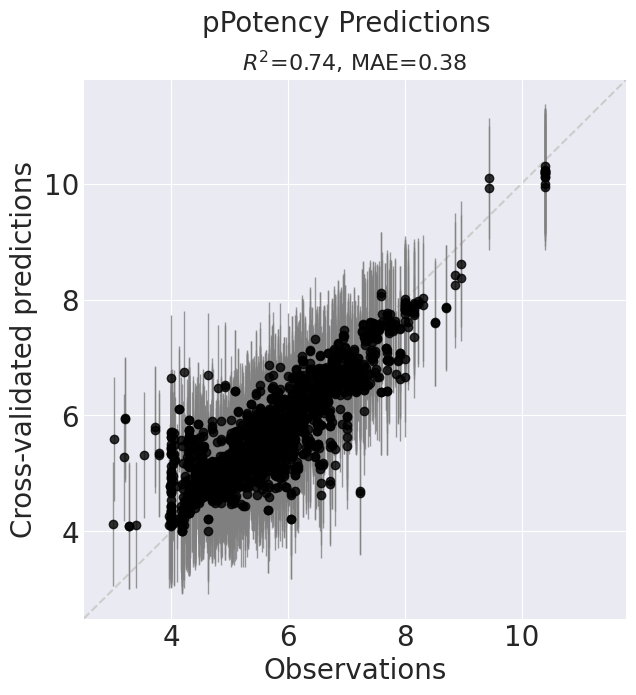

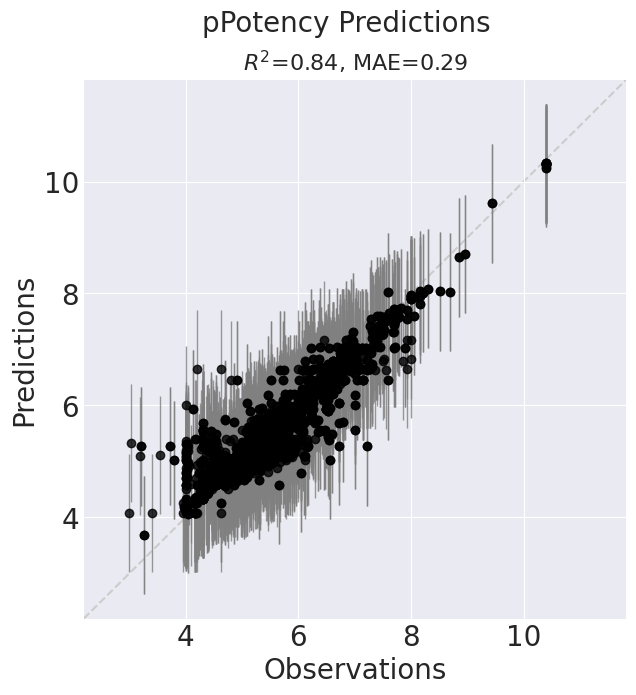

In [51]:
ARTtrainedModelFile = os.path.join(artResultDir, "art.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art.output_dir = artResultDir
os.makedirs(art.output_dir, exist_ok=True)

print(f"ART output directory: {art.output_dir}")

# Generate both ART plots
predictions_vs_observations(
    art,
    cv=True,
    error_bars=True
)

predictions_vs_observations(
    art,
    cv=False,
    error_bars=True
)

# 4.1 Find external validation with pre-trained `ART` models

### `All buyable` Antivirals 

In [58]:
combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW = pd.read_csv(saveDir + "/Ebola_all_Buyable_AntiVirals_wMACAW.csv")

print(f"Total buyable antiviral molecules before removing training set molecules: {len(combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW)}")

# Get the set of training SMILES from the chEMBL data for fast lookup
training_smiles_set = set(combinedEbolaVirusData_allDB_wMACAW['Smiles'])

# Remove rows whose SMILES are present in the training data
combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW = combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW[
    ~combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW['SMILES'].isin(training_smiles_set)
].reset_index(drop=True)

removed_count = len(training_smiles_set) - (len(training_smiles_set) - (len(combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW)))
print(f"Training set molecules found and removed: {len(pd.read_csv(modelBuildingDataDir + '/Ebola_all_Buyable_AntiVirals_wMACAW.csv')) - len(combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW)}")

combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW

Total buyable antiviral molecules before removing training set molecules: 113185
Training set molecules found and removed: 0
Total buyable antiviral molecules for external validation after removing training set molecules: 113185


,SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals,0.163188,0.010665,0.100069,-0.008223,-0.027650,0.004309,0.045641,-0.025008,...,0.002336,0.026218,-0.012065,0.034036,-0.018928,-0.001542,0.006843,-0.007888,0.004028,-0.018840
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals,0.153488,0.039773,0.035338,-0.034237,0.038506,0.006182,0.001180,-0.051615,...,-0.009579,0.065903,-0.016783,0.017391,-0.005033,-0.019989,0.008674,0.037965,-0.021767,-0.016314
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals,0.134157,0.094931,-0.005144,0.010614,-0.058898,-0.077540,-0.037010,-0.034163,...,-0.019402,-0.010920,-0.045763,-0.002688,0.002134,0.018743,-0.032947,-0.041270,-0.007732,0.043300
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals,0.144502,0.091445,0.046280,0.040235,-0.005475,0.004569,-0.004175,-0.053368,...,0.003060,-0.000775,-0.042689,0.015361,-0.040790,-0.006960,0.021390,0.005561,-0.013953,0.025152
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals,0.116260,0.089705,-0.010596,0.002804,0.035979,-0.059483,-0.023975,-0.009068,...,-0.012479,0.006727,-0.055945,0.028399,-0.028961,0.013343,0.030555,0.006383,-0.020247,0.027761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals,-0.040890,-0.058225,0.007993,-0.002179,-0.042269,-0.013869,0.049008,-0.009579,...,0.003130,-0.012098,0.001273,0.015099,0.001681,0.019310,-0.017965,-0.018264,-0.056098,-0.003941
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals,-0.021636,-0.058727,-0.012759,-0.038758,-0.035212,-0.008368,0.064578,-0.013869,...,-0.014527,-0.003818,0.019584,0.019176,-0.005241,0.018815,-0.012379,-0.016634,-0.037283,-0.006192
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals,-0.005976,-0.043697,0.001513,-0.019411,-0.056869,-0.003552,0.039723,-0.020399,...,-0.000166,0.006890,-0.003872,-0.013710,-0.003273,0.033865,-0.005759,-0.012965,-0.009705,-0.003161
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals,0.016218,-0.115361,0.069993,-0.012943,-0.032962,-0.049116,0.104731,0.052267,...,0.000538,0.008606,-0.015765,0.024548,-0.038704,0.015783,-0.016396,-0.051538,-0.031712,0.015840


In [59]:
macaw_columns = [col for col in combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [60]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smiLib)

# Now use these for your results
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction = combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW[['SMILES', 'source_DataBase']].copy()

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_prediction'] = mean
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'])
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'])

# Select and save results
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction = combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.filter(
    items=["SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.to_csv(os.path.join(saveDir + "/combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.csv"), index=False)
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction[['SMILES']].to_csv(os.path.join(saveDir + "/combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction

Predictions saved with uncertainty estimates


,SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals,5.105670,0.545426,4.036636,6.174704,0.000008,6.687996e-07,0.000092
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals,5.007438,0.547443,3.934450,6.080427,0.000010,8.309468e-07,0.000116
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals,4.819532,0.541383,3.758420,5.880643,0.000015,1.316305e-06,0.000174
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals,5.087139,0.546747,4.015516,6.158762,0.000008,6.938054e-07,0.000096
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals,5.392557,0.543045,4.328189,6.456925,0.000004,3.492006e-07,0.000047
...,...,...,...,...,...,...,...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals,5.484249,0.540973,4.423942,6.544555,0.000003,2.853942e-07,0.000038
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals,5.403186,0.539742,4.345291,6.461081,0.000004,3.458748e-07,0.000045
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals,5.406166,0.541336,4.345146,6.467185,0.000004,3.410477e-07,0.000045
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals,5.376473,0.541037,4.316041,6.436905,0.000004,3.656748e-07,0.000048


### Plot prediction probability

Molecule 1: mean=6.400, std=0.547, 95% CI=[5.334, 7.460], IC50=0.3979 µM
Molecule 2: mean=6.228, std=0.546, 95% CI=[5.185, 7.290], IC50=0.5909 µM
Molecule 3: mean=6.142, std=0.543, 95% CI=[5.082, 7.200], IC50=0.7203 µM
Molecule 4: mean=6.130, std=0.542, 95% CI=[5.087, 7.198], IC50=0.7418 µM
Molecule 5: mean=6.121, std=0.546, 95% CI=[5.052, 7.193], IC50=0.7569 µM
Molecule 6: mean=6.119, std=0.534, 95% CI=[5.080, 7.168], IC50=0.7606 µM
Molecule 7: mean=6.083, std=0.546, 95% CI=[5.007, 7.144], IC50=0.8265 µM
Molecule 8: mean=6.064, std=0.547, 95% CI=[4.986, 7.106], IC50=0.8636 µM
Molecule 9: mean=6.067, std=0.554, 95% CI=[5.005, 7.142], IC50=0.8563 µM
Molecule 10: mean=6.072, std=0.541, 95% CI=[4.984, 7.099], IC50=0.8469 µM
Molecule 11: mean=6.074, std=0.562, 95% CI=[4.970, 7.165], IC50=0.8426 µM
Molecule 12: mean=6.067, std=0.550, 95% CI=[4.980, 7.174], IC50=0.8577 µM
Molecule 13: mean=6.063, std=0.546, 95% CI=[5.001, 7.121], IC50=0.8653 µM
Molecule 14: mean=6.076, std=0.551, 95% CI=[4.9

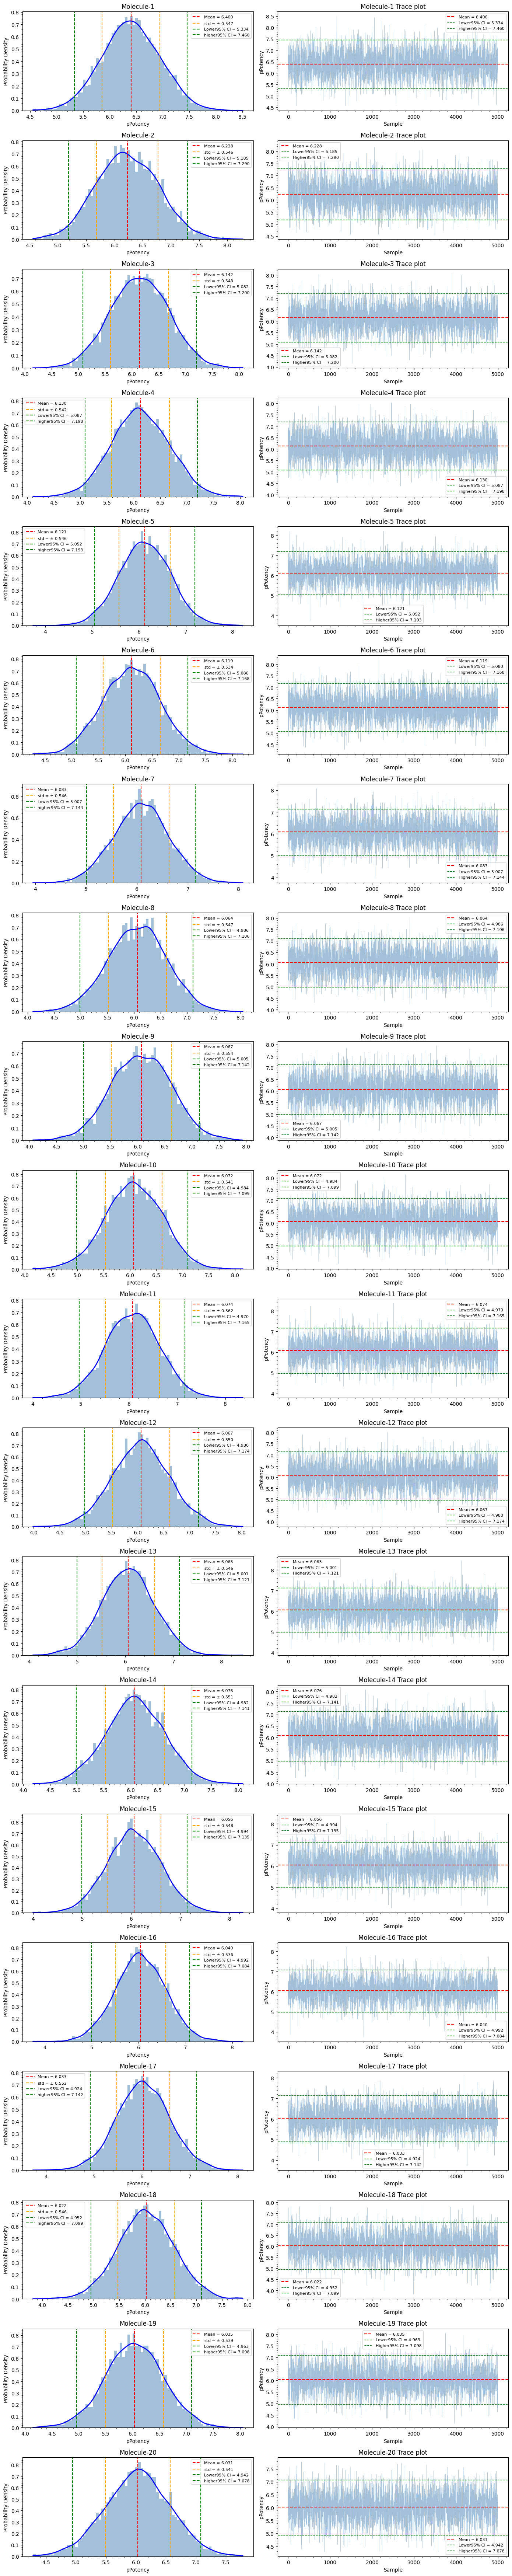

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['SMILES', *macaw_cols]], on='SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction,
    feat_df=combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)

### Rank molecules by `best probability`

- SMILES: the molecule identifier.
- P(pPotency>=4): estimated as
$$\frac{\#\{\text{posterior draws }\ge 4\}}{n\_samples}$$
(0.93 means 93% of posterior predictive samples are ≥ 4)
- post_mean: average of posterior draws (Bayesian estimate of expected pPotency).
- post_std: spread of posterior draws (predictive uncertainty).
- post_q05 / post_q95 (or 2.5/97.5): predictive interval quantiles.




In [62]:
def rankByProbGeThreshold(predDf, featDf, art, threshold=4.0,
                          topN=20, nSamples=5000, candidatePool=None):
    macawCols = [c for c in featDf.columns if c.startswith("MACAW_")]

    # Choose how many molecules to evaluate (all if candidatePool is None)
    if candidatePool is None:
        candDf = predDf.copy()
    else:
        candDf = (
            predDf.sort_values("pPotency_prediction", ascending=False)
                  .head(candidatePool)
                  .copy()
        )

    # Include source_DataBase if present in predDf
    baseCols = ["SMILES", "pPotency_prediction"]
    if "source_DataBase" in candDf.columns:
        baseCols.insert(1, "source_DataBase")  # keep it next to SMILES

    mergedDf = (
        candDf[baseCols]
        .merge(featDf[["SMILES", *macawCols]], on="SMILES", how="inner")
        .drop_duplicates("SMILES")
        .reset_index(drop=True)
    )
    if mergedDf.empty:
        raise ValueError("No molecules matched between predDf and featDf on SMILES.")

    probs = []
    postMeans = []
    postStds = []
    q05s = []
    q95s = []

    for _, row in mergedDf.iterrows():
        x = row[macawCols].to_numpy(dtype=float).reshape(1, -1)
        draws = np.asarray(art.post_pred_draws(x, n_samples=nSamples)).ravel()

        probs.append(np.mean(draws >= threshold))
        postMeans.append(draws.mean())
        postStds.append(draws.std(ddof=1))
        q05, q95 = np.percentile(draws, [5, 95])
        q05s.append(q05)
        q95s.append(q95)

    rankedDf = mergedDf[baseCols].copy()
    rankedDf["probPotencyGeThreshold"] = probs
    rankedDf["postMean"] = postMeans
    rankedDf["postStd"]  = postStds
    rankedDf["postQ05"]  = q05s
    rankedDf["postQ95"]  = q95s

    rankedDf = rankedDf.sort_values(
        ["probPotencyGeThreshold", "postMean"],
        ascending=[False, False]
    )
    return rankedDf.head(topN).reset_index(drop=True)

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability_top20 = rankByProbGeThreshold(
    predDf=combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction,
    featDf=combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW,
    art=art,
    threshold=5.0,
    topN=20,
    nSamples=5000,
    candidatePool=500
)

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability_top20

,SMILES,source_DataBase,pPotency_prediction,probPotencyGeThreshold,postMean,postStd,postQ05,postQ95
0,O=C(N1CCCC1)C12CC3CC(C1)CC(c1ccccc1)(C3)C2,LifeChemicals_Antivirals,6.410318,0.9956,6.409682,0.541061,5.507943,7.298695
1,O=C(NC1=NCCS1)C12CC3CC(C1)CC(c1ccccc1)(C3)C2,LifeChemicals_Antivirals,6.221260,0.9874,6.224522,0.546135,5.355923,7.130367
2,CCOC(=O)c1c(C)n(-c2ccc(OC)cc2)c2ccc(O)c(CN3CCN...,ChemDiv_Antivirals,6.152266,0.9820,6.154354,0.547498,5.266374,7.053847
3,COc1ccc(-c2c(-c3ccc(OCCN4CCCCC4)cc3O)n[nH]c2C)...,LifeChemicals_Antivirals,6.110766,0.9782,6.114327,0.556537,5.189414,7.039120
4,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CNCCC...,LifeChemicals_Antivirals,6.065463,0.9772,6.078300,0.528399,5.214436,6.951640
5,COc1ccc(-c2nn3c(NCCCN4CCOCC4)cc(C)nc3c2C)cc1OC,LifeChemicals_Antivirals,6.075341,0.9764,6.060892,0.551664,5.183218,6.984921
6,COc1ccc(-c2c(-c3ccc(OCCN4CCOCC4)cc3O)n[nH]c2C)...,LifeChemicals_Antivirals,6.117604,0.9762,6.118413,0.537097,5.241010,6.987236
7,CCN(CC)CCNC(=O)C(C1CCCC1)N1CCN(C(=O)Nc2ccccc2)CC1,ChemDiv_Antivirals,6.115866,0.9756,6.103386,0.554488,5.196444,6.993590
8,CCOC(=O)COc1ccc2c(c1)O/C(=C\c1cc(OC)c(OC)cc1OC...,LifeChemicals_Antivirals,6.047164,0.9754,6.055376,0.542185,5.177515,6.953978
9,CCOC(=O)c1c(C)n(-c2ccccc2)c2cc(Br)c(O)c(CN3CCC...,ChemDiv_Antivirals,6.090113,0.9752,6.089899,0.547139,5.186536,6.984914


## 4.2 `Inosine + Adenosine + Guanosine + Xanthosine`

Find external validation with pre-trained `ART` models for DORAnet generated molecules

In [67]:
def canonicalize(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else smi

# Load DORAnet generated molecules
Ebola_allDORAnetGenerated_Antivirals_wMACAW = pd.read_csv(
    saveDir + "/Ebola_allDORAnetGenerated_Antivirals_wMACAW.csv"
)

total_before = len(Ebola_allDORAnetGenerated_Antivirals_wMACAW)
print(f"Total DORAnet generated molecules before removing training set molecules: {total_before}")

# Training set stats
total_training_rows = len(combinedEbolaVirusData_allDB_wMACAW)
unique_training_smiles = combinedEbolaVirusData_allDB_wMACAW['Smiles'].nunique()
duplicate_training_smiles = combinedEbolaVirusData_allDB_wMACAW['Smiles'].duplicated().sum()
print(f"Total training set SMILES: {total_training_rows}")
print(f"Unique training set SMILES: {unique_training_smiles}")
print(f"Duplicate training set SMILES: {duplicate_training_smiles}")

# Canonicalize training SMILES for consistent matching
training_smiles_set = set(combinedEbolaVirusData_allDB_wMACAW['Smiles'].apply(canonicalize))
print(f"Unique canonical training SMILES: {len(training_smiles_set)}")

# Canonicalize DORAnet SMILES and remove matches
Ebola_allDORAnetGenerated_Antivirals_wMACAW['canonical_SMILES'] = \
    Ebola_allDORAnetGenerated_Antivirals_wMACAW['SMILES'].apply(canonicalize)

Ebola_allDORAnetGenerated_Antivirals_wMACAW = \
    Ebola_allDORAnetGenerated_Antivirals_wMACAW[
        ~Ebola_allDORAnetGenerated_Antivirals_wMACAW['canonical_SMILES'].isin(training_smiles_set)
    ].drop(columns=['canonical_SMILES']).reset_index(drop=True)

total_after = len(Ebola_allDORAnetGenerated_Antivirals_wMACAW)
print(f"\nTraining set molecules found and removed: {total_before - total_after}")
print(f"Total DORAnet generated molecules for external validation: {total_after}")

Ebola_allDORAnetGenerated_Antivirals_wMACAW

Total DORAnet generated molecules before removing training set molecules: 20372
Total training set SMILES: 1954
Unique training set SMILES: 667
Duplicate training set SMILES: 1287
Unique canonical training SMILES: 667

Training set molecules found and removed: 0
Total DORAnet generated molecules for external validation: 20372


,SMILES,Is_Starter,SourceDirectories,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,0.198556,-0.038594,0.196612,-0.191335,-0.051828,0.135890,-0.134896,...,0.057510,0.008632,-0.000814,0.035407,-0.048322,-0.014627,-0.016158,-0.007848,-0.009703,0.034153
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,0.034152,-0.071527,0.164790,-0.072358,0.017499,0.014963,-0.055491,...,0.034385,-0.013572,-0.010744,-0.011032,-0.026339,0.015227,0.002475,0.005588,-0.032115,0.002364
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,0.140310,-0.052569,0.186787,-0.155597,-0.023353,0.078480,-0.109581,...,0.027393,-0.027603,-0.012267,0.015189,-0.035375,-0.009253,0.013985,0.013028,0.005221,0.029229
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,-0.144934,-0.080400,0.173883,-0.004967,0.022418,-0.058935,-0.002376,...,0.016294,-0.003244,0.002187,0.013559,0.011383,0.002003,-0.004000,0.012689,0.001641,-0.007204
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,-0.155930,-0.075359,0.164917,-0.003582,0.017690,-0.063040,-0.002396,...,0.017553,-0.011901,0.000954,0.011055,0.007963,-0.006276,-0.002336,0.008001,0.006370,0.002023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,0.154788,-0.042899,0.164218,-0.137893,-0.031336,0.090332,-0.053345,...,0.030536,0.025837,-0.012517,0.021357,-0.029296,0.015251,-0.018060,-0.010461,-0.009164,0.013465
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,0.097933,-0.063727,0.147090,-0.101024,-0.012814,0.051877,-0.016472,...,0.010094,0.014320,-0.016488,0.012416,-0.018784,0.014740,-0.017800,0.004505,0.007514,0.006298
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,0.104405,-0.070191,0.142945,-0.090783,-0.021899,0.055979,-0.019653,...,0.005552,0.010228,-0.001030,0.005425,-0.025837,0.034914,-0.022287,-0.006863,-0.000608,-0.006175
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,0.134399,-0.060088,0.143049,-0.116435,-0.025801,0.055696,-0.018878,...,0.014209,-0.009427,-0.013710,0.022088,-0.039484,0.024314,-0.031594,-0.013583,-0.006042,0.010748


In [68]:
macaw_columns = [col for col in Ebola_allDORAnetGenerated_Antivirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = Ebola_allDORAnetGenerated_Antivirals_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [69]:
chunk_size = 50000
total_rows = len(Ebola_allDORAnetGenerated_Antivirals_wMACAW)
print(f"Total molecules to predict: {total_rows}")
print(f"Processing in chunks of {chunk_size}...")

macaw_cols = [col for col in Ebola_allDORAnetGenerated_Antivirals_wMACAW.columns if col.startswith('MACAW_')]

output_path = os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv")
smiles_output_path = os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_ARTprediction_SMILESonly.csv")

if os.path.exists(output_path):
    os.remove(output_path)
if os.path.exists(smiles_output_path):
    os.remove(smiles_output_path)

header_written = False

for start in range(0, total_rows, chunk_size):
    end = min(start + chunk_size, total_rows)
    print(f"  Processing chunk {start} - {end} ({end}/{total_rows})...")

    chunk_features = Ebola_allDORAnetGenerated_Antivirals_wMACAW.iloc[start:end][macaw_cols].values
    chunk_smiles = Ebola_allDORAnetGenerated_Antivirals_wMACAW.iloc[start:end]['SMILES'].values
    chunk_is_starter = Ebola_allDORAnetGenerated_Antivirals_wMACAW.iloc[start:end]['Is_Starter'].values
    chunk_source_dirs = Ebola_allDORAnetGenerated_Antivirals_wMACAW.iloc[start:end]['SourceDirectories'].values

    mean, std = art.post_pred_stats(chunk_features)
    mean = np.array(mean).flatten()
    std = np.array(std).flatten()

    chunk_df = pd.DataFrame({
        'SMILES': chunk_smiles,
        'Is_Starter': chunk_is_starter,
        'SourceDirectories': chunk_source_dirs,
        'pPotency_prediction': mean,
        'pPotency_std': std,
        'pPotency_lower_95CI': mean - 1.96 * std,
        'pPotency_upper_95CI': mean + 1.96 * std,
        'IC50(M)_prediction': 10 ** (-mean),
        'IC50(M)_lower_95CI': 10 ** (-(mean + 1.96 * std)),
        'IC50(M)_upper_95CI': 10 ** (-(mean - 1.96 * std)),
    })

    chunk_df.to_csv(output_path, mode='a', header=not header_written, index=False)
    chunk_df[['SMILES']].to_csv(smiles_output_path, mode='a', header=not header_written, index=False)
    header_written = True

    del chunk_features, chunk_smiles, chunk_is_starter, chunk_source_dirs, mean, std, chunk_df
    gc.collect()

print(f"\nPredictions saved to: {output_path}")
print(f"SMILES-only saved to: {smiles_output_path}")

Ebola_allDORAnetGenerated_Antivirals_ARTprediction = pd.read_csv(output_path)
print(f"Total predictions: {len(Ebola_allDORAnetGenerated_Antivirals_ARTprediction)}")
Ebola_allDORAnetGenerated_Antivirals_ARTprediction

Total molecules to predict: 20372
Processing in chunks of 50000...
  Processing chunk 0 - 20372 (20372/20372)...

Predictions saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv
SMILES-only saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/Ebola_allDORAnetGenerated_Antivirals_ARTprediction_SMILESonly.csv
Total predictions: 20372


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,5.260644,0.540668,4.200935,6.320352,0.000005,4.782418e-07,0.000063
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040
...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,5.255267,0.543298,4.190404,6.320131,0.000006,4.784854e-07,0.000065
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.260999,0.542954,4.196810,6.325188,0.000005,4.729461e-07,0.000064
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.269796,0.541144,4.209154,6.330439,0.000005,4.672626e-07,0.000062
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,5.209218,0.543006,4.144925,6.273511,0.000006,5.327083e-07,0.000072


Molecule 1: mean=5.632, std=0.556, 95% CI=[4.540, 6.729], IC50=2.3316 µM
Molecule 2: mean=5.621, std=0.553, 95% CI=[4.531, 6.713], IC50=2.3949 µM
Molecule 3: mean=5.603, std=0.546, 95% CI=[4.529, 6.668], IC50=2.4933 µM
Molecule 4: mean=5.608, std=0.542, 95% CI=[4.571, 6.686], IC50=2.4633 µM
Molecule 5: mean=5.594, std=0.539, 95% CI=[4.565, 6.658], IC50=2.5496 µM
Molecule 6: mean=5.591, std=0.542, 95% CI=[4.558, 6.660], IC50=2.5655 µM
Molecule 7: mean=5.584, std=0.546, 95% CI=[4.496, 6.648], IC50=2.6082 µM
Molecule 8: mean=5.578, std=0.547, 95% CI=[4.514, 6.663], IC50=2.6434 µM
Molecule 9: mean=5.586, std=0.545, 95% CI=[4.529, 6.673], IC50=2.5951 µM
Molecule 10: mean=5.574, std=0.538, 95% CI=[4.517, 6.626], IC50=2.6652 µM
Molecule 11: mean=5.559, std=0.544, 95% CI=[4.491, 6.619], IC50=2.7632 µM
Molecule 12: mean=5.560, std=0.532, 95% CI=[4.523, 6.587], IC50=2.7563 µM
Molecule 13: mean=5.555, std=0.534, 95% CI=[4.510, 6.596], IC50=2.7863 µM
Molecule 14: mean=5.540, std=0.550, 95% CI=[4.4

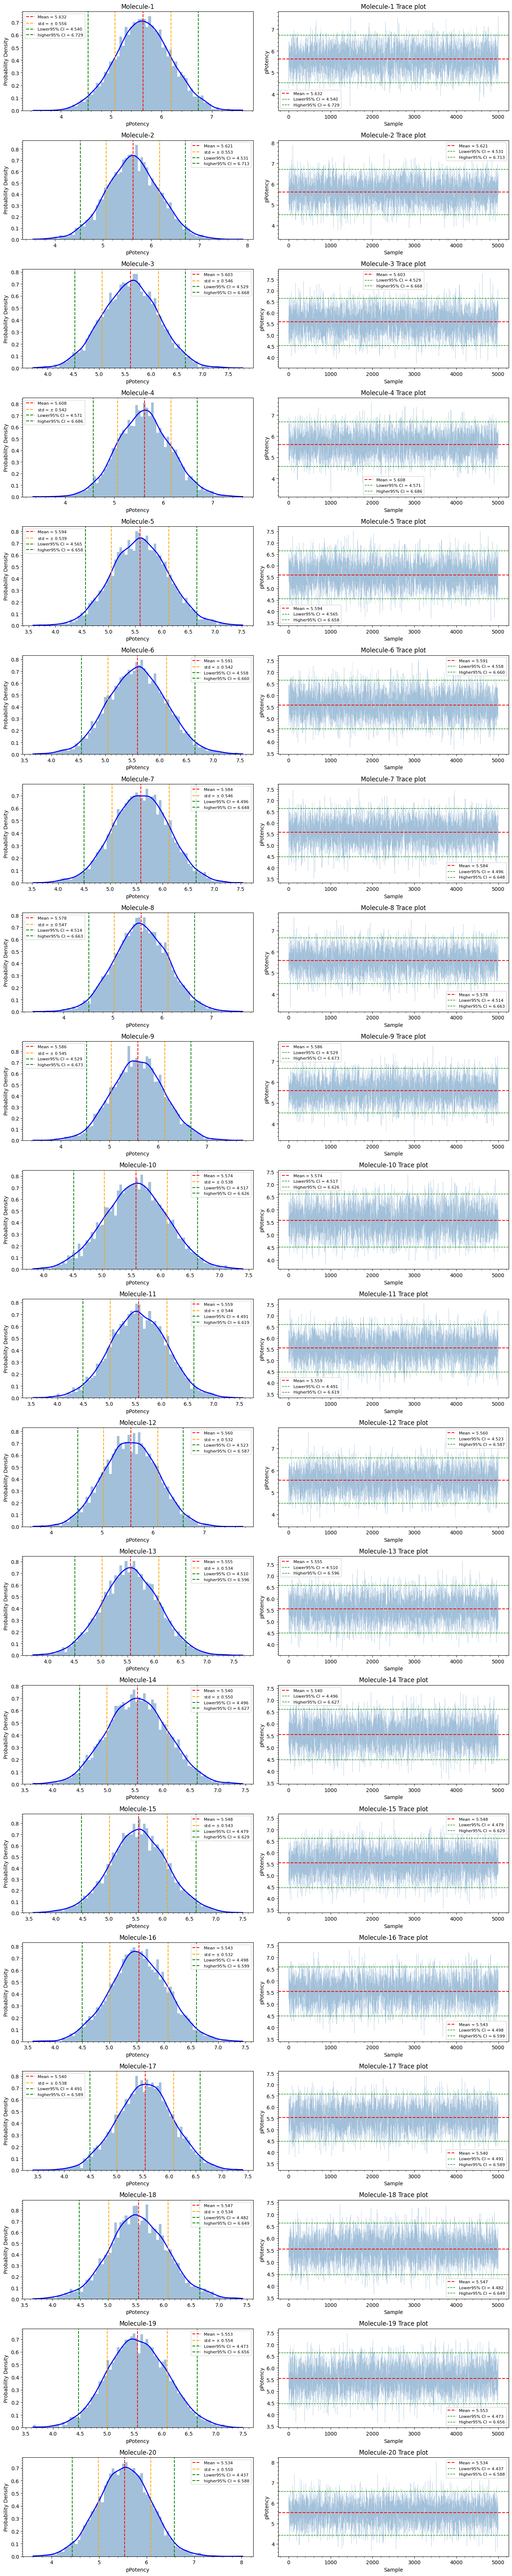

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['SMILES', *macaw_cols]], on='SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=Ebola_allDORAnetGenerated_Antivirals_ARTprediction,
    feat_df=Ebola_allDORAnetGenerated_Antivirals_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)

## 4.3 `InosineSubstructures`: Find external validation with pre-trained `ART` models for DORAnet generated molecules

In [71]:
combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW = pd.read_csv(saveDir + "/combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.csv")

total_before = len(combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW)
print(f"Total DORAnet generated molecules before removing training set molecules: {total_before}")

# Get the set of training SMILES from the chEMBL data for fast lookup
training_smiles_set = set(combinedEbolaVirusData_allDB_wMACAW['Smiles'])

# Remove rows whose SMILES are present in the training data
combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW = combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW[
    ~combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW['SMILES'].isin(training_smiles_set)
].reset_index(drop=True)

total_after = len(combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW)
print(f"Training set molecules found and removed: {total_before - total_after}")
print(f"Total DORAnet generated molecules for external validation: {total_after}")

combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW

Total DORAnet generated molecules before removing training set molecules: 20880
Training set molecules found and removed: 0
Total DORAnet generated molecules for external validation: 20880


,SMILES,Is_Starter,SourceDirectories,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,0.034152,-0.071527,0.164790,-0.072358,0.017499,0.014963,...,0.034385,-0.013572,-0.010744,-0.011032,-0.026339,0.015227,0.002475,0.005588,-0.032115,0.002364
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,0.140310,-0.052569,0.186787,-0.155597,-0.023353,0.078480,...,0.027393,-0.027603,-0.012267,0.015189,-0.035375,-0.009253,0.013985,0.013028,0.005221,0.029229
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,-0.144934,-0.080400,0.173883,-0.004967,0.022418,-0.058935,...,0.016294,-0.003244,0.002187,0.013559,0.011383,0.002003,-0.004000,0.012689,0.001641,-0.007204
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,-0.155930,-0.075359,0.164917,-0.003582,0.017690,-0.063040,...,0.017553,-0.011901,0.000954,0.011055,0.007963,-0.006276,-0.002336,0.008001,0.006370,0.002023
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,0.076764,-0.068153,0.164824,-0.113838,0.003792,0.057865,...,0.020606,-0.017132,-0.005726,0.016628,-0.031903,0.012964,0.015103,-0.008449,-0.021800,0.007404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20875,O=C1Oc2nc3c(c(=O)[nH]2)n1c[n+]3[C@@H]1O[C@H](C...,False,starter_00352,Inosine_Substructures,0.135289,-0.037909,0.154456,-0.118971,-0.018775,0.091074,...,0.015633,0.019628,-0.038368,0.000583,-0.017145,0.019839,-0.016400,-0.000246,-0.030729,-0.001410
20876,O=C(O)n1c[n+]([C@@H]2O[C@H](C(O)O)[C@@H](O)[C@...,False,starter_00352,Inosine_Substructures,0.132876,-0.042161,0.167667,-0.151759,-0.022749,0.089160,...,0.013938,-0.003963,-0.030081,0.017075,-0.009326,0.016487,-0.022993,-0.009375,-0.005904,0.008516
20877,N#CC(O)(O)[C@H]1O[C@@H]([n+]2cn(C(=O)O)c3c(=O)...,False,starter_00352,Inosine_Substructures,0.094259,-0.028187,0.172829,-0.125952,-0.022647,0.080690,...,0.010992,0.007757,-0.034463,0.020601,-0.001336,-0.000494,-0.007634,-0.000324,-0.009436,0.017140
20878,NC(=O)[C@H]1O[C@@H]([n+]2cn(C(=O)O)c3c(=O)[nH]...,False,starter_00352,Inosine_Substructures,0.120627,-0.059342,0.154111,-0.137082,-0.018653,0.082028,...,0.008411,0.006860,-0.011151,0.007432,-0.001825,0.037292,-0.018592,0.000717,0.001728,0.007227


In [72]:
macaw_columns = [col for col in combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [73]:
# Process predictions in chunks
chunk_size = 100000
total_rows = len(combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW)
print(f"Total molecules to predict: {total_rows}")
print(f"Processing in chunks of {chunk_size}...")

# Prepare the MACAW feature columns
macaw_cols = [col for col in combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]

# Output paths
output_path = os.path.join(saveDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.csv")
smiles_output_path = os.path.join(saveDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction_SMILESonly.csv")

# Remove existing files to avoid appending to old results
if os.path.exists(output_path):
    os.remove(output_path)
if os.path.exists(smiles_output_path):
    os.remove(smiles_output_path)

header_written = False

for start in range(0, total_rows, chunk_size):
    end = min(start + chunk_size, total_rows)
    print(f"  Processing chunk {start} - {end} ({end}/{total_rows})...")

    # Extract chunk features
    chunk_features = combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.iloc[start:end][macaw_cols].values
    chunk_smiles = combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.iloc[start:end]['SMILES'].values

    # Get predictions for this chunk
    mean, std = art.post_pred_stats(chunk_features)

    # Flatten in case they are 2D arrays
    mean = np.array(mean).flatten()
    std = np.array(std).flatten()

    # Build chunk results
    chunk_df = pd.DataFrame({
        'SMILES': chunk_smiles,
        'pPotency_prediction': mean,
        'pPotency_std': std,
        'pPotency_lower_95CI': mean - 1.96 * std,
        'pPotency_upper_95CI': mean + 1.96 * std,
        'IC50(M)_prediction': 10 ** (-mean),
        'IC50(M)_lower_95CI': 10 ** (-(mean + 1.96 * std)),
        'IC50(M)_upper_95CI': 10 ** (-(mean - 1.96 * std)),
    })

    # Append to CSV
    chunk_df.to_csv(output_path, mode='a', header=not header_written, index=False)
    chunk_df[['SMILES']].to_csv(smiles_output_path, mode='a', header=not header_written, index=False)
    header_written = True

    # Free memory
    del chunk_features, chunk_smiles, mean, std, chunk_df
    gc.collect()

print(f"\nPredictions saved to: {output_path}")
print(f"SMILES-only saved to: {smiles_output_path}")

# Read back if needed for display
combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction = pd.read_csv(output_path)
print(f"Total predictions: {len(combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction)}")
combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.head()

Total molecules to predict: 20880
Processing in chunks of 100000...
  Processing chunk 0 - 20880 (20880/20880)...

Predictions saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.csv
SMILES-only saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction_SMILESonly.csv
Total predictions: 20880


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,5.260644,0.540668,4.200935,6.320352,0.000005,4.782418e-07,0.000063
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.315121,0.543254,4.250343,6.379898,0.000005,4.169669e-07,0.000056


### Plot the probability distribution

Molecule 1: mean=5.622, std=0.545, 95% CI=[4.546, 6.690], IC50=2.3890 µM
Molecule 2: mean=5.613, std=0.539, 95% CI=[4.571, 6.672], IC50=2.4352 µM
Molecule 3: mean=5.592, std=0.543, 95% CI=[4.537, 6.643], IC50=2.5565 µM
Molecule 4: mean=5.549, std=0.542, 95% CI=[4.500, 6.602], IC50=2.8221 µM


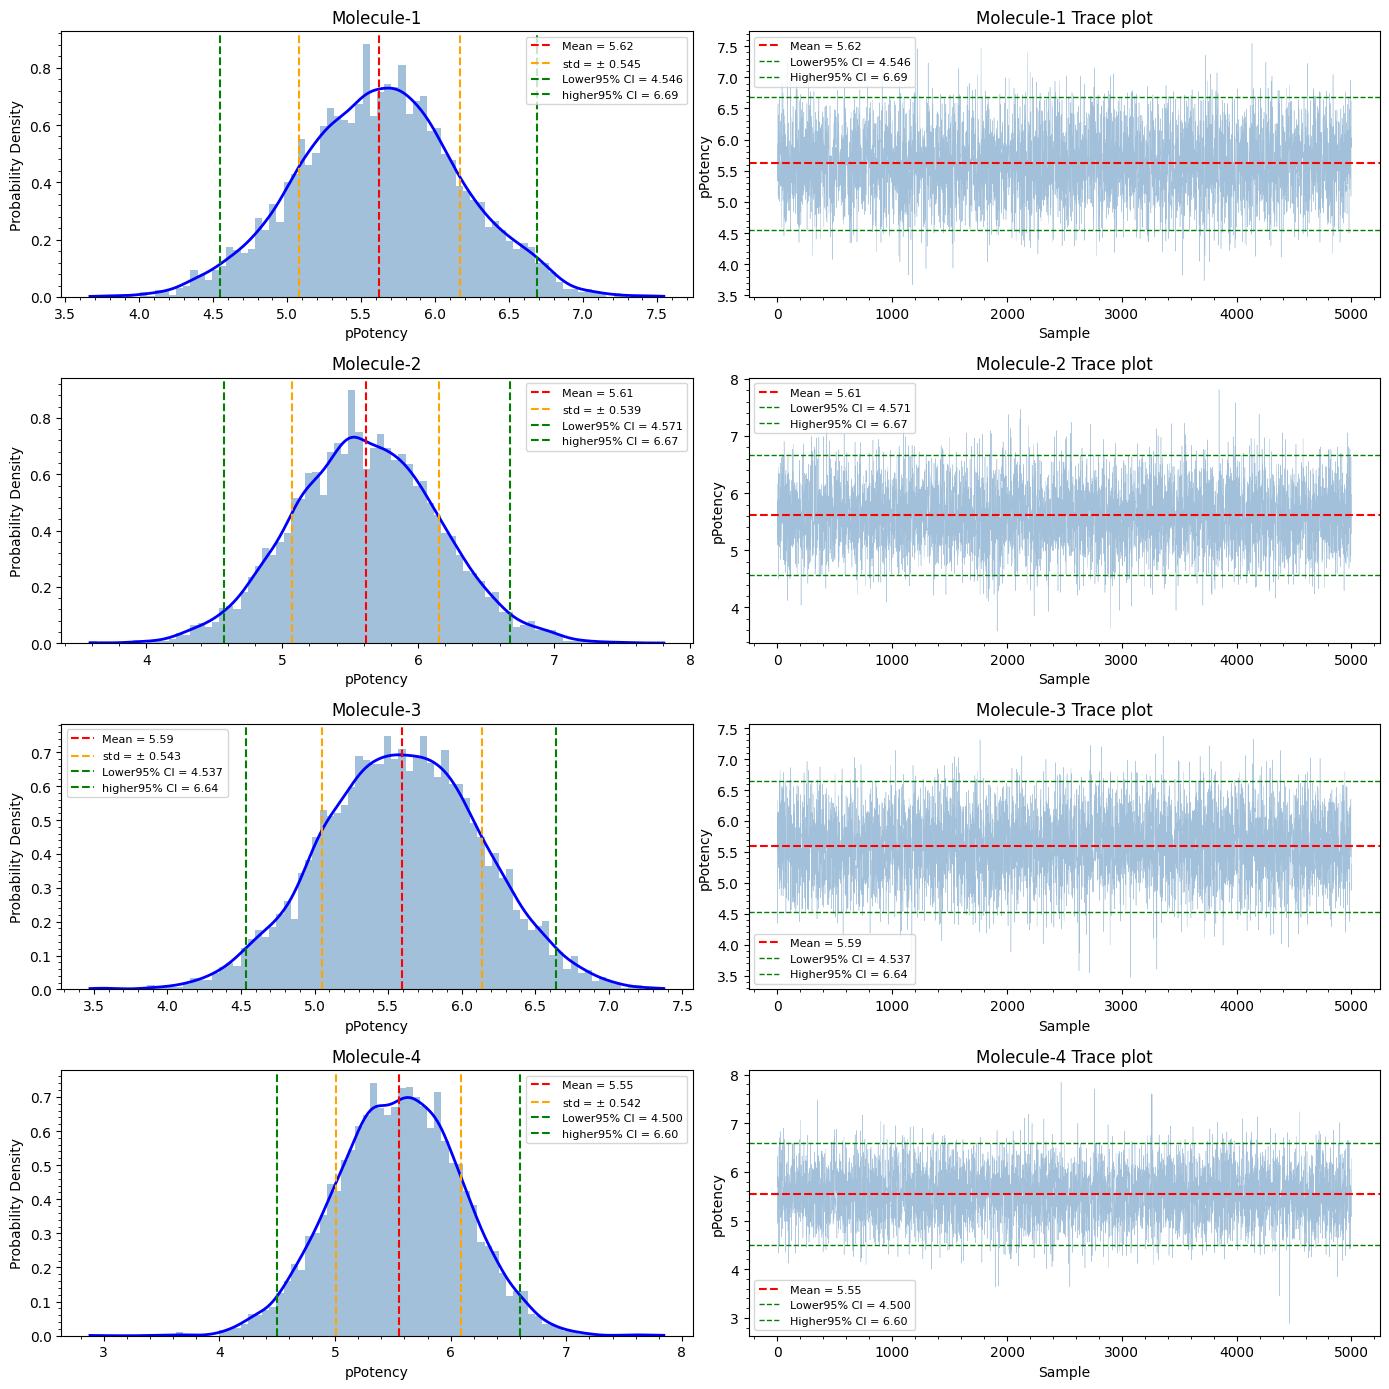

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['SMILES', *macaw_cols]], on='SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.2f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.2f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.2f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction,
    feat_df=Ebola_allDORAnetGenerated_Antivirals_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)

### 4.4 Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [75]:
combinedEbolaVirus_DTRA_target_antivirals_wMACAW = pd.read_csv(saveDir + "/combinedEbolaVirusData_DTRA_target_Antiviral_SMILES_wMACAW.csv")
combinedEbolaVirus_DTRA_target_antivirals_wMACAW

,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.59,-0.211091,-0.164819,0.338714,-0.026474,0.115983,-0.181729,...,-0.000012,-0.004654,-0.020814,-0.050107,0.040863,-0.012432,-0.033618,0.013280,-0.008476,-0.003786
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.31,0.106048,-0.046744,0.175127,-0.069323,0.017728,0.052945,...,-0.032602,0.022668,-0.018894,0.023465,0.000765,0.028447,0.004308,0.013922,-0.030133,0.011030


In [76]:
macaw_columns = [col for col in combinedEbolaVirus_DTRA_target_antivirals_wMACAW.columns if col.startswith('MACAW_')]
smi_lib_DTRA_target_antivirals_wMACAW = combinedEbolaVirus_DTRA_target_antivirals_wMACAW[macaw_columns].values

Get predictions with uncertainty using ART's post_pred_stats

In [77]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smi_lib_DTRA_target_antivirals_wMACAW)

# Now use these for your results
DTRA_target_antivirals_predicted = combinedEbolaVirus_DTRA_target_antivirals_wMACAW[['SMILES']].copy()
DTRA_target_antivirals_predicted['pPotency_prediction'] = mean
DTRA_target_antivirals_predicted['pPotency_std'] = std

# Calculate 95% Confidence Intervals
DTRA_target_antivirals_predicted['pPotency_lower_95CI'] = mean - 1.96 * std
DTRA_target_antivirals_predicted['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
DTRA_target_antivirals_predicted['IC50(M)_prediction'] = 10 ** (-mean)
DTRA_target_antivirals_predicted['IC50(M)_lower_95CI'] = 10 ** (-DTRA_target_antivirals_predicted['pPotency_upper_95CI'])
DTRA_target_antivirals_predicted['IC50(M)_upper_95CI'] = 10 ** (-DTRA_target_antivirals_predicted['pPotency_lower_95CI'])

# Select and save results
DTRA_target_antivirals_predicted = DTRA_target_antivirals_predicted.filter(
    items=["SMILES", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

DTRA_target_antivirals_predicted.to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_DTRA_target_antivirals_predicted_all.csv"), index=False)
DTRA_target_antivirals_predicted[['SMILES']].to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_DTRA_target_antivirals_predicted_all_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
DTRA_target_antivirals_predicted

Predictions saved with uncertainty estimates


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,6.652206,0.538861,5.596039,7.708373,2.227379e-07,1.957163e-08,0.000003
1,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,5.122924,0.542265,4.060084,6.185764,7.534879e-06,6.519831e-07,0.000087


## 4.5 Find external validation with pre-trained `ART` models for `FDA` approved `antivirals`

In [79]:
combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW = pd.read_csv(saveDir + "/combinedEbolaVirusData_drugBankDrug_FDAapproved_Antiviral_wMACAW.csv")

total_before = len(combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW)
print(f"Total DORAnet generated molecules before removing training set molecules: {total_before}")

# Get the set of training SMILES from the chEMBL data for fast lookup
training_smiles_set = set(combinedEbolaVirusData_allDB_wMACAW['Smiles'])

# Remove rows whose SMILES are present in the training data
combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW = combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW[
    ~combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW['smiles'].isin(training_smiles_set)
].reset_index(drop=True)

total_after = len(combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW)
print(f"Training set molecules found and removed: {total_before - total_after}")
print(f"Total DORAnet generated molecules for external validation: {total_after}")

combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW

Total DORAnet generated molecules before removing training set molecules: 75
Training set molecules found and removed: 0
Total DORAnet generated molecules for external validation: 75


,Unnamed: 0,smiles,ATC_code,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,286.339,1.09230,7,3,4.0,0.727230,...,0.017776,-0.003912,0.002795,0.013989,0.006600,0.001364,0.025869,-0.029535,0.008706,0.040602
1,1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,225.208,-1.33180,7,3,4.0,0.554386,...,0.034185,0.018333,-0.007932,0.000440,0.013616,-0.013602,-0.000068,-0.020646,0.005923,0.016222
2,2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,501.477,2.70250,13,1,2.0,0.207152,...,0.005876,0.033216,-0.019614,-0.002652,-0.058832,0.007098,-0.013836,0.021547,0.036994,0.001799
3,3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,505.637,2.40280,7,3,3.0,0.399740,...,-0.019084,-0.001278,0.008934,0.021279,0.003984,-0.029073,0.003196,0.023784,-0.027538,-0.006804
4,4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,748.299,3.85380,10,3,3.0,0.285739,...,0.019720,-0.004430,-0.023635,0.033109,-0.031898,-0.017778,-0.017551,-0.003128,-0.010474,0.008608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,72,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,J05AB,antiviral,267.245,-1.98000,9,4,4.0,0.490520,...,0.064074,-0.012784,0.002567,0.038547,-0.057691,-0.020023,0.011001,-0.011508,-0.016709,0.054963
71,73,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,J05AP,antiviral,868.948,4.95650,11,3,2.0,0.303895,...,-0.020290,-0.012639,-0.036392,0.026130,-0.029165,-0.015454,-0.040085,0.022177,-0.008249,0.023822
72,74,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,J05AF,antiviral,211.221,-0.50460,6,2,4.0,0.687546,...,0.014690,0.052937,-0.020911,-0.004622,0.019025,-0.015289,0.013576,0.013930,-0.057587,-0.001783
73,75,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,J05AH,antiviral,332.313,-3.78550,7,7,3.0,0.188042,...,0.025064,0.017118,-0.021140,0.014214,-0.031457,0.004654,-0.014079,0.005050,-0.011609,-0.012501


In [80]:
macaw_columns = [col for col in combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [82]:
# Process predictions in chunks
chunk_size = 100000
total_rows = len(combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW)
print(f"Total molecules to predict: {total_rows}")
print(f"Processing in chunks of {chunk_size}...")

# Prepare the MACAW feature columns
macaw_cols = [col for col in combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW.columns if col.startswith('MACAW_')]

# Output paths
output_path = os.path.join(saveDir, "combinedEbolaVirusData_FDA_approved_Antivirals_ARTprediction.csv")
smiles_output_path = os.path.join(saveDir, "combinedEbolaVirusData_FDA_approved_Antivirals_ARTprediction_SMILESonly.csv")

# Remove existing files to avoid appending to old results
if os.path.exists(output_path):
    os.remove(output_path)
if os.path.exists(smiles_output_path):
    os.remove(smiles_output_path)

header_written = False

for start in range(0, total_rows, chunk_size):
    end = min(start + chunk_size, total_rows)
    print(f"  Processing chunk {start} - {end} ({end}/{total_rows})...")

    # Extract chunk features
    chunk_features = combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW.iloc[start:end][macaw_cols].values
    chunk_smiles = combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW.iloc[start:end]['smiles'].values

    # Get predictions for this chunk
    mean, std = art.post_pred_stats(chunk_features)

    # Flatten in case they are 2D arrays
    mean = np.array(mean).flatten()
    std = np.array(std).flatten()

    # Build chunk results
    chunk_df = pd.DataFrame({
        'smiles': chunk_smiles,
        'pPotency_prediction': mean,
        'pPotency_std': std,
        'pPotency_lower_95CI': mean - 1.96 * std,
        'pPotency_upper_95CI': mean + 1.96 * std,
        'IC50(M)_prediction': 10 ** (-mean),
        'IC50(M)_lower_95CI': 10 ** (-(mean + 1.96 * std)),
        'IC50(M)_upper_95CI': 10 ** (-(mean - 1.96 * std)),
    })

    # Append to CSV
    chunk_df.to_csv(output_path, mode='a', header=not header_written, index=False)
    chunk_df[['smiles']].to_csv(smiles_output_path, mode='a', header=not header_written, index=False)
    header_written = True

    # Free memory
    del chunk_features, chunk_smiles, mean, std, chunk_df
    gc.collect()

print(f"\nPredictions saved to: {output_path}")
print(f"SMILES-only saved to: {smiles_output_path}")

# Read back if needed for display
combinedEbolaVirusData_FDA_approved_Antivirals_ARTprediction = pd.read_csv(output_path)
print(f"Total predictions: {len(combinedEbolaVirusData_FDA_approved_Antivirals_ARTprediction)}")
combinedEbolaVirusData_FDA_approved_Antivirals_ARTprediction.head()

Total molecules to predict: 75
Processing in chunks of 100000...
  Processing chunk 0 - 75 (75/75)...

Predictions saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirusData_FDA_approved_Antivirals_ARTprediction.csv
SMILES-only saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirusData_FDA_approved_Antivirals_ARTprediction_SMILESonly.csv
Total predictions: 75


,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,0.000067
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,0.000106
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,0.000068
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,0.000077
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,0.000027


### Plot the probability distribution

Molecule 1: mean=5.878, std=0.541, 95% CI=[4.802, 6.932], IC50=1.3250 µM
Molecule 2: mean=5.775, std=0.548, 95% CI=[4.705, 6.836], IC50=1.6794 µM
Molecule 3: mean=5.771, std=0.544, 95% CI=[4.737, 6.830], IC50=1.6925 µM
Molecule 4: mean=5.720, std=0.547, 95% CI=[4.633, 6.763], IC50=1.9049 µM
Molecule 5: mean=5.683, std=0.543, 95% CI=[4.616, 6.748], IC50=2.0773 µM
Molecule 6: mean=5.668, std=0.544, 95% CI=[4.620, 6.715], IC50=2.1460 µM
Molecule 7: mean=5.667, std=0.538, 95% CI=[4.604, 6.718], IC50=2.1526 µM
Molecule 8: mean=5.671, std=0.549, 95% CI=[4.604, 6.753], IC50=2.1320 µM
Molecule 9: mean=5.655, std=0.538, 95% CI=[4.617, 6.745], IC50=2.2113 µM
Molecule 10: mean=5.624, std=0.543, 95% CI=[4.566, 6.675], IC50=2.3788 µM
Molecule 11: mean=5.628, std=0.557, 95% CI=[4.526, 6.681], IC50=2.3578 µM
Molecule 12: mean=5.614, std=0.543, 95% CI=[4.551, 6.683], IC50=2.4302 µM
Molecule 13: mean=5.614, std=0.540, 95% CI=[4.559, 6.659], IC50=2.4331 µM
Molecule 14: mean=5.597, std=0.541, 95% CI=[4.5

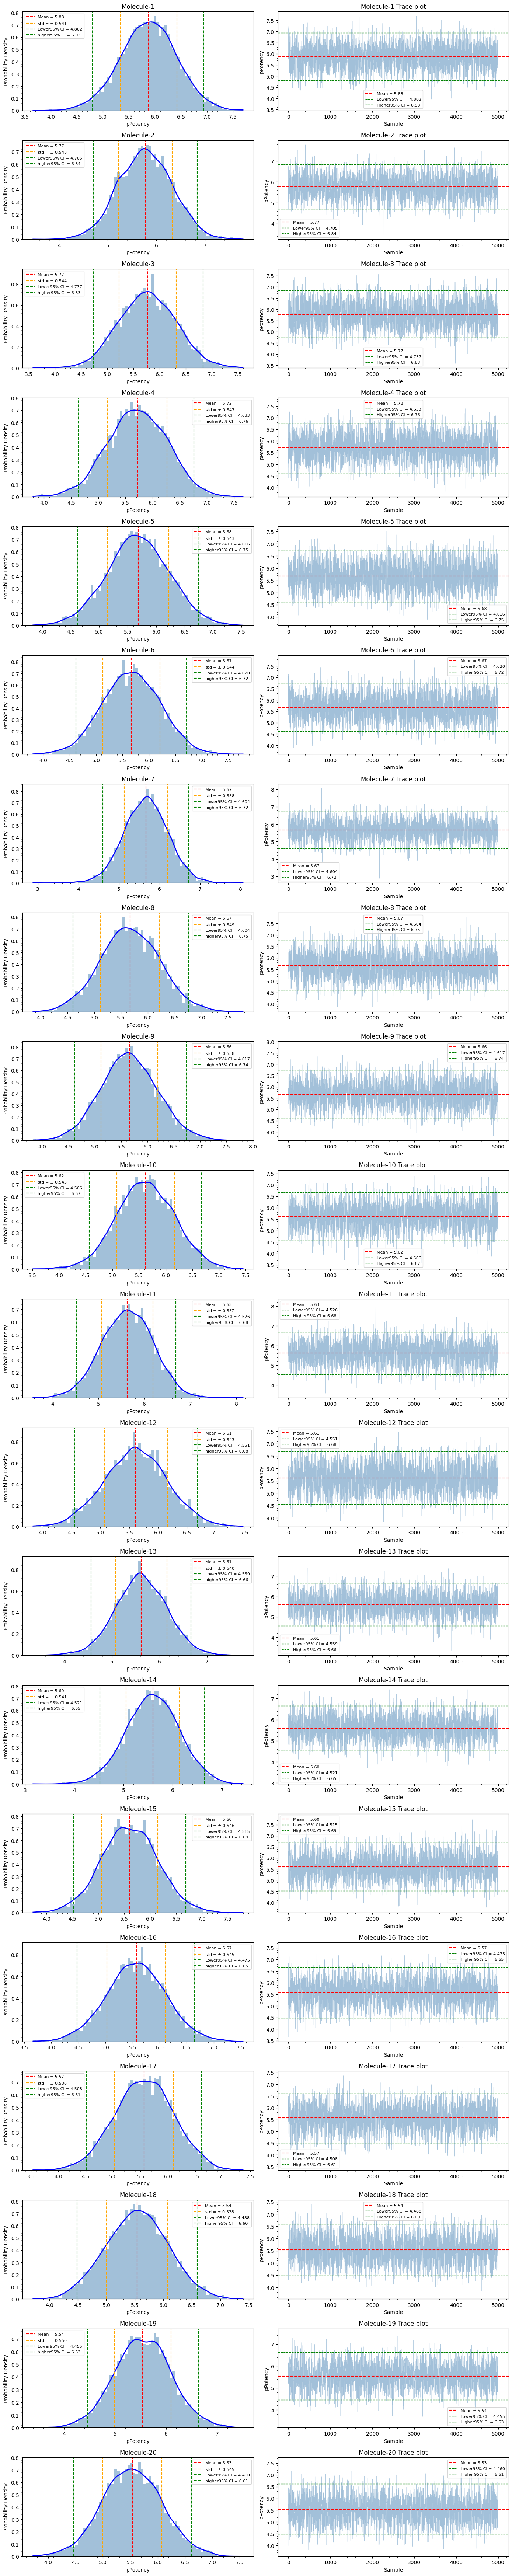

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['smiles', *macaw_cols]], on='smiles', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['smiles']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.2f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.2f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.2f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirusData_FDA_approved_Antivirals_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirusData_FDA_approved_Antivirals_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=combinedEbolaVirusData_FDA_approved_Antivirals_ARTprediction,
    feat_df=combinedEbolaVirusData_FDA_approved_Antivirals_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)